# Práctica 1 - Predicción de Subscripción a un Producto Bancario

**Asignatura:** Aprendizaje Automático 2025-26  
**Grupo:**
- Pablo García Aparicio
- Miguel Merino Sánchez

**NIA:** 100522190  
**Fichero de datos:** `bank_09.pkl`

---
> **Nota sobre IA generativa:** En esta practica hemos usadado la IA generativa para ayudarnos a comporbar el codigo base de pipelines y verificar la logica de los preprocesamientos.

In [1]:
# ─── Imports globales ───────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import time
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, LabelEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# Semilla reproducibilidad = NIA
SEED = 100522190
np.random.seed(SEED)

# Estilo gráficos
sns.set_theme(style='whitegrid', palette='muted')
matplotlib.rcParams['figure.dpi'] = 100

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga de datos

In [2]:
df = pd.read_pickle('bank_09.pkl')
print(f'Dataset cargado: {df.shape[0]} instancias, {df.shape[1]} variables')
df.head()

Dataset cargado: 11000 instancias, 17 variables


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


---
## 2. EDA Simplificado

Analizamos de forma sistemática y mediante código el dataset para guiar el preprocesamiento.


In [3]:
# ── 2.1 Dimensiones y tipos 
print(f'Filas: {df.shape[0]}, Columnas: {df.shape[1]}')
print('\n--- Tipos de datos ---')
print(df.dtypes)

Filas: 11000, Columnas: 17

--- Tipos de datos ---
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object


In [4]:
# ── 2.2 Clasificación de variables 
TARGET = 'deposit'
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Quitar target de las listas si estuviera
if TARGET in num_cols: num_cols.remove(TARGET)
if TARGET in cat_cols: cat_cols.remove(TARGET)

print(f'Variables NUMÉRICAS ({len(num_cols)}): {num_cols}')
print(f'Variables CATEGÓRICAS ({len(cat_cols)}): {cat_cols}')
print(f'Variable objetivo: {TARGET} (tipo: {df[TARGET].dtype})')

Variables NUMÉRICAS (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Variables CATEGÓRICAS (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Variable objetivo: deposit (tipo: object)


In [5]:
# ── 2.3 Alta cardinalidad (> 10 valores únicos) 
print('\n--- Cardinalidad variables categóricas ---')
card_df = pd.DataFrame({
    'variable': cat_cols,
    'n_unique': [df[c].nunique() for c in cat_cols],
    'valores': [list(df[c].unique()) for c in cat_cols]
}).sort_values('n_unique', ascending=False)
print(card_df.to_string(index=False))

alta_card = card_df[card_df['n_unique'] > 10]['variable'].tolist()
print(f'\nVariables con alta cardinalidad (>10): {alta_card if alta_card else "Ninguna"}')


--- Cardinalidad variables categóricas ---
 variable  n_unique                                                                                                                                      valores
      job        12 [admin., technician, services, management, None, blue-collar, unemployed, entrepreneur, housemaid, retired, unknown, self-employed, student]
    month        12                                                                                 [may, jun, jul, aug, oct, nov, dec, jan, feb, mar, apr, sep]
education         4                                                                                                      [secondary, tertiary, primary, unknown]
 poutcome         4                                                                                                           [unknown, other, failure, success]
  marital         3                                                                                                            [married, single, divorc

In [6]:
# ── 2.4 Valores faltantes 
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['missing'] > 0].sort_values('missing', ascending=False)
if missing_df.empty:
    print('No hay valores faltantes en el dataset.')
else:
    print('Variables con valores faltantes:')
    print(missing_df)

Variables con valores faltantes:
         missing   pct
marital      282  2.56
job           97  0.88


In [7]:
# ── 2.5 Columnas constantes o de ID 
constant_cols = [c for c in df.columns if df[c].nunique() <= 1]
print(f'Columnas constantes: {constant_cols if constant_cols else "Ninguna"}')

# Heurística ID: nombres con 'id' y alta cardinalidad
id_cols = [c for c in df.columns if 'id' in c.lower() and df[c].nunique() == len(df)]
print(f'Posibles columnas ID: {id_cols if id_cols else "Ninguna"}')

Columnas constantes: Ninguna
Posibles columnas ID: Ninguna


Variable objetivo: "deposit"
         count  pct (%)
deposit                
no        5780    52.55
yes       5220    47.45

Ratio mayoritaria/minoritaria: 1.11
CONCLUSIÓN: Problema de CLASIFICACIÓN BINARIA.
El dataset está moderadamente balanceado (ratio <= 3).


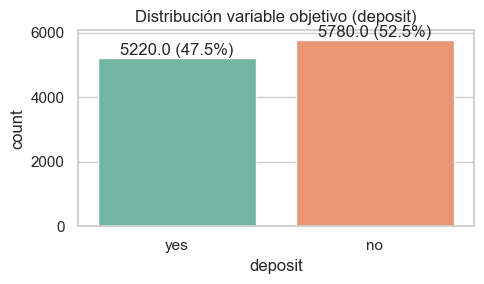

In [8]:
# ── 2.6 Tipo de problema y balance de clases 
print(f'Variable objetivo: "{TARGET}"')
counts = df[TARGET].value_counts()
pcts = df[TARGET].value_counts(normalize=True) * 100
balance_df = pd.DataFrame({'count': counts, 'pct (%)': pcts.round(2)})
print(balance_df)

ratio = counts.max() / counts.min()
print(f'\nRatio mayoritaria/minoritaria: {ratio:.2f}')
print('CONCLUSIÓN: Problema de CLASIFICACIÓN BINARIA.')
if ratio > 3:
    print('El dataset está DESBALANCEADO (ratio > 3).')
else:
    print('El dataset está moderadamente balanceado (ratio <= 3).')

# Gráfico
fig, ax = plt.subplots(figsize=(5, 3))
sns.countplot(x=TARGET, data=df, ax=ax, palette='Set2')
ax.set_title('Distribución variable objetivo (deposit)')
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig('eda_balance_clases.png')
plt.show()

In [9]:
# ── 2.7 Análisis especial de pdays 
print('--- Análisis de pdays ---')
print(f'Valores únicos de pdays: {sorted(df["pdays"].unique()[:10])} ...')
print(f'Mínimo: {df["pdays"].min()}, Máximo: {df["pdays"].max()}')
print(f'Instancias con pdays == -1: {(df["pdays"] == -1).sum()} ({(df["pdays"] == -1).mean()*100:.1f}%)')

print('''
ANÁLISIS: La columna pdays tiene valor -1 para indicar que el cliente
NO fue contactado en la campaña anterior (no es un valor faltante normal).
Este -1 especial distorsionaría el escalado y los modelos.

ESTRATEGIA DE PREPROCESAMIENTO:
1. Crear una variable binaria 'pdays_contactado' (1 si fue contactado, 0 si no).
2. Reemplazar los -1 en 'pdays' por NaN, luego imputar con la mediana (solo
   de los clientes que sí fueron contactados), o directamente por 0.
   Esto se hará dentro de la pipeline con SimpleImputer.
''')

--- Análisis de pdays ---
Valores únicos de pdays: [np.int64(-1), np.int64(91), np.int64(110), np.int64(126), np.int64(147), np.int64(150), np.int64(166), np.int64(170), np.int64(171), np.int64(182)] ...
Mínimo: -1, Máximo: 854
Instancias con pdays == -1: 8203 (74.6%)

ANÁLISIS: La columna pdays tiene valor -1 para indicar que el cliente
NO fue contactado en la campaña anterior (no es un valor faltante normal).
Este -1 especial distorsionaría el escalado y los modelos.

ESTRATEGIA DE PREPROCESAMIENTO:
1. Crear una variable binaria 'pdays_contactado' (1 si fue contactado, 0 si no).
2. Reemplazar los -1 en 'pdays' por NaN, luego imputar con la mediana (solo
   de los clientes que sí fueron contactados), o directamente por 0.
   Esto se hará dentro de la pipeline con SimpleImputer.



In [10]:
# ── 2.8 Preprocesamiento de pdays (aplicado ya en EDA) 
# Feature engineering: indicador de contacto previo
df['pdays_contactado'] = (df['pdays'] != -1).astype(int)
# Reemplazar -1 por NaN (se imputará en la pipeline más adelante)
df['pdays'] = df['pdays'].replace(-1, np.nan)

print('pdays transformado: -1 → NaN, nueva columna pdays_contactado creada.')
print(f"\nNaN en pdays ahora: {df['pdays'].isna().sum()}")
print(f"Distribución pdays_contactado:\n{df['pdays_contactado'].value_counts()}")

# Actualizar lista de columnas numéricas
num_cols.append('pdays_contactado')
print('\nResumen EDA completado.')

pdays transformado: -1 → NaN, nueva columna pdays_contactado creada.

NaN en pdays ahora: 8203
Distribución pdays_contactado:
pdays_contactado
0    8203
1    2797
Name: count, dtype: int64

Resumen EDA completado.


In [11]:
# ── 2.9 Estadísticas descriptivas 
print('--- Variables numéricas ---')
display(df[num_cols].describe().round(2))
print('\n--- Variables categóricas ---')
display(df[cat_cols].describe())

--- Variables numéricas ---


,age,balance,day,duration,campaign,pdays,previous,pdays_contactado
count,11000.00,11000.00,11000.00,11000.00,11000.00,2797.00,11000.00,11000.00
mean,41.25,1529.14,15.66,372.52,2.51,204.72,0.83,0.25
std,11.94,3217.40,8.42,347.52,2.72,122.40,2.28,0.44
min,18.00,-6847.00,1.00,2.00,1.00,1.00,0.00,0.00
25%,32.00,122.75,8.00,138.00,1.00,98.00,0.00,0.00
50%,39.00,549.50,15.00,255.00,2.00,182.00,0.00,0.00
75%,49.00,1711.00,22.00,498.00,3.00,286.00,1.00,1.00
max,95.00,81204.00,31.00,3881.00,63.00,854.00,58.00,1.00



--- Variables categóricas ---


,job,marital,education,default,housing,loan,contact,month,poutcome
count,10903,10718,11000,11000,11000,11000,11000,11000,11000
unique,12,3,4,2,2,2,3,12,4
top,management,married,secondary,no,no,no,cellular,may,unknown
freq,2498,6114,5393,10833,5801,9569,7922,2780,8205


---
## 3. Evaluación: Train/Test split y métricas

### Decisiones:
- **Evaluación outer (estimación rendimiento futuro):** Holdout 2/3 train – 1/3 test, estratificado.
- **Métrica principal:** `ROC-AUC` — adecuada para clasificación binaria con posible desbalance. Mide la capacidad discriminativa del modelo con independencia del umbral de decisión.
- **Evaluación inner (HPO y comparación modelos):** `StratifiedKFold` con 5 folds.

In [12]:
# ── Preparar X, y ────────────────────────────────────────────────────────
TARGET = 'deposit'
y = df[TARGET]
X = df.drop(columns=[TARGET])

# Codificar target (yes→1, no→0)
le = LabelEncoder()
y = pd.Series(le.fit_transform(y), name=TARGET)
print(f'Clases target: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# ── Split 2/3 train / 1/3 test ────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape[0]} instancias | Test: {X_test.shape[0]} instancias')
print(f'Distribución en train: {y_train.value_counts().to_dict()}')
print(f'Distribución en test:  {y_test.value_counts().to_dict()}')

# ── Evaluación inner: StratifiedKFold 5 folds ─────────────────────────────
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
METRIC = 'roc_auc'
print(f'\nMétrica principal: {METRIC}')
print(f'CV inner: StratifiedKFold(n_splits=5, shuffle=True, random_state={SEED})')

Clases target: {'no': np.int64(0), 'yes': np.int64(1)}
Train: 7333 instancias | Test: 3667 instancias
Distribución en train: {0: 3853, 1: 3480}
Distribución en test:  {0: 1927, 1: 1740}

Métrica principal: roc_auc
CV inner: StratifiedKFold(n_splits=5, shuffle=True, random_state=100522190)


In [13]:
# ── Columnas por tipo (actualizadas post-EDA) ─────────────────────────────
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Numéricas: {num_features}')
print(f'Categóricas: {cat_features}')

Numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'pdays_contactado']
Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


---
## 4. Métodos Básicos: KNN y Árboles

### 4.1 Selección del método de escalado con KNN

In [14]:
# ── Función auxiliar: construir preprocesador ──────────────────────────────
def make_preprocessor(scaler):
    """Crea un ColumnTransformer con el scaler indicado para numéricas
    y OneHotEncoder para categóricas."""
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', scaler)
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer([
        ('num', num_pipe, num_features),
        ('cat', cat_pipe, cat_features)
    ])

print('Función make_preprocessor definida.')


Función make_preprocessor definida.


In [15]:
# ── Comparación de escaladores con KNN (k=5 por defecto) ──────────────────
scalers = {
    'MinMaxScaler': MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler()
}

scaling_results = []
for name, scaler in scalers.items():
    pipe = Pipeline([
        ('preprocessor', make_preprocessor(scaler)),
        ('clf', KNeighborsClassifier())
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_inner,
                              scoring=METRIC, n_jobs=-1)
    scaling_results.append({
        'Escalador': name,
        f'ROC-AUC mean': scores.mean().round(4),
        f'ROC-AUC std': scores.std().round(4)
    })

scaling_df = pd.DataFrame(scaling_results).sort_values('ROC-AUC mean', ascending=False)
print('--- Comparación escaladores (KNN, k=5) ---')
display(scaling_df)

BEST_SCALER_NAME = scaling_df.iloc[0]['Escalador']
BEST_SCALER = scalers[BEST_SCALER_NAME]
print(f'\n→ Mejor escalador: {BEST_SCALER_NAME}')


--- Comparación escaladores (KNN, k=5) ---


,Escalador,ROC-AUC mean,ROC-AUC std
1,StandardScaler,0.8732,0.0093
2,RobustScaler,0.8521,0.0097
0,MinMaxScaler,0.7993,0.0091



→ Mejor escalador: StandardScaler


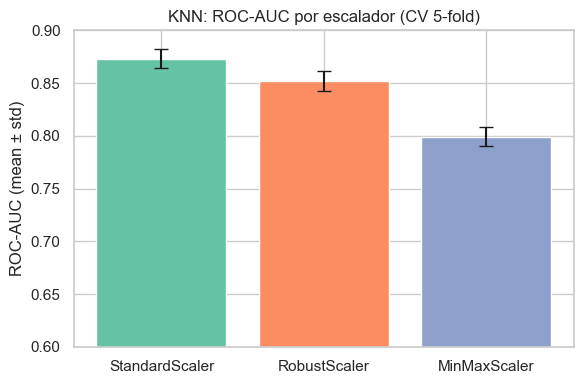

In [16]:
# Gráfico comparación escaladores
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(scaling_df['Escalador'], scaling_df['ROC-AUC mean'],
       yerr=scaling_df['ROC-AUC std'], capsize=5, color=sns.color_palette('Set2', 3))
ax.set_ylim(0.6, 0.9)
ax.set_title('KNN: ROC-AUC por escalador (CV 5-fold)')
ax.set_ylabel('ROC-AUC (mean ± std)')
plt.tight_layout()
plt.savefig('escaladores_knn.png')
plt.show()


### 4.2 Evaluación con hiperparámetros por defecto


In [17]:
# ── Modelos base con parámetros por defecto ───────────────────────────────
# Preprocesador con el mejor escalador
preprocessor = make_preprocessor(BEST_SCALER)

models_default = {
    'Dummy (most_frequent)': Pipeline([
        ('pre', make_preprocessor(StandardScaler())),
        ('clf', DummyClassifier(strategy='most_frequent', random_state=SEED))
    ]),
    'KNN (k=5)': Pipeline([
        ('pre', make_preprocessor(BEST_SCALER)),
        ('clf', KNeighborsClassifier())
    ]),
    'DecisionTree': Pipeline([
        ('pre', make_preprocessor(StandardScaler())),
        ('clf', DecisionTreeClassifier(random_state=SEED))
    ])
}

default_results = []
for name, pipe in models_default.items():
    t0 = time.time()
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_inner,
                              scoring=METRIC, n_jobs=-1)
    elapsed = time.time() - t0
    default_results.append({
        'Modelo': name,
        'ROC-AUC mean': scores.mean().round(4),
        'ROC-AUC std': scores.std().round(4),
        'Tiempo (s)': round(elapsed, 2)
    })

results_df = pd.DataFrame(default_results).sort_values('ROC-AUC mean', ascending=False)
print('--- Modelos con hiperparámetros por defecto ---')
display(results_df)

--- Modelos con hiperparámetros por defecto ---


,Modelo,ROC-AUC mean,ROC-AUC std,Tiempo (s)
1,KNN (k=5),0.8732,0.0093,0.19
2,DecisionTree,0.7983,0.0101,0.46
0,Dummy (most_frequent),0.5000,0.0000,0.12


### 4.3 Árbol poco profundo – Interpretación


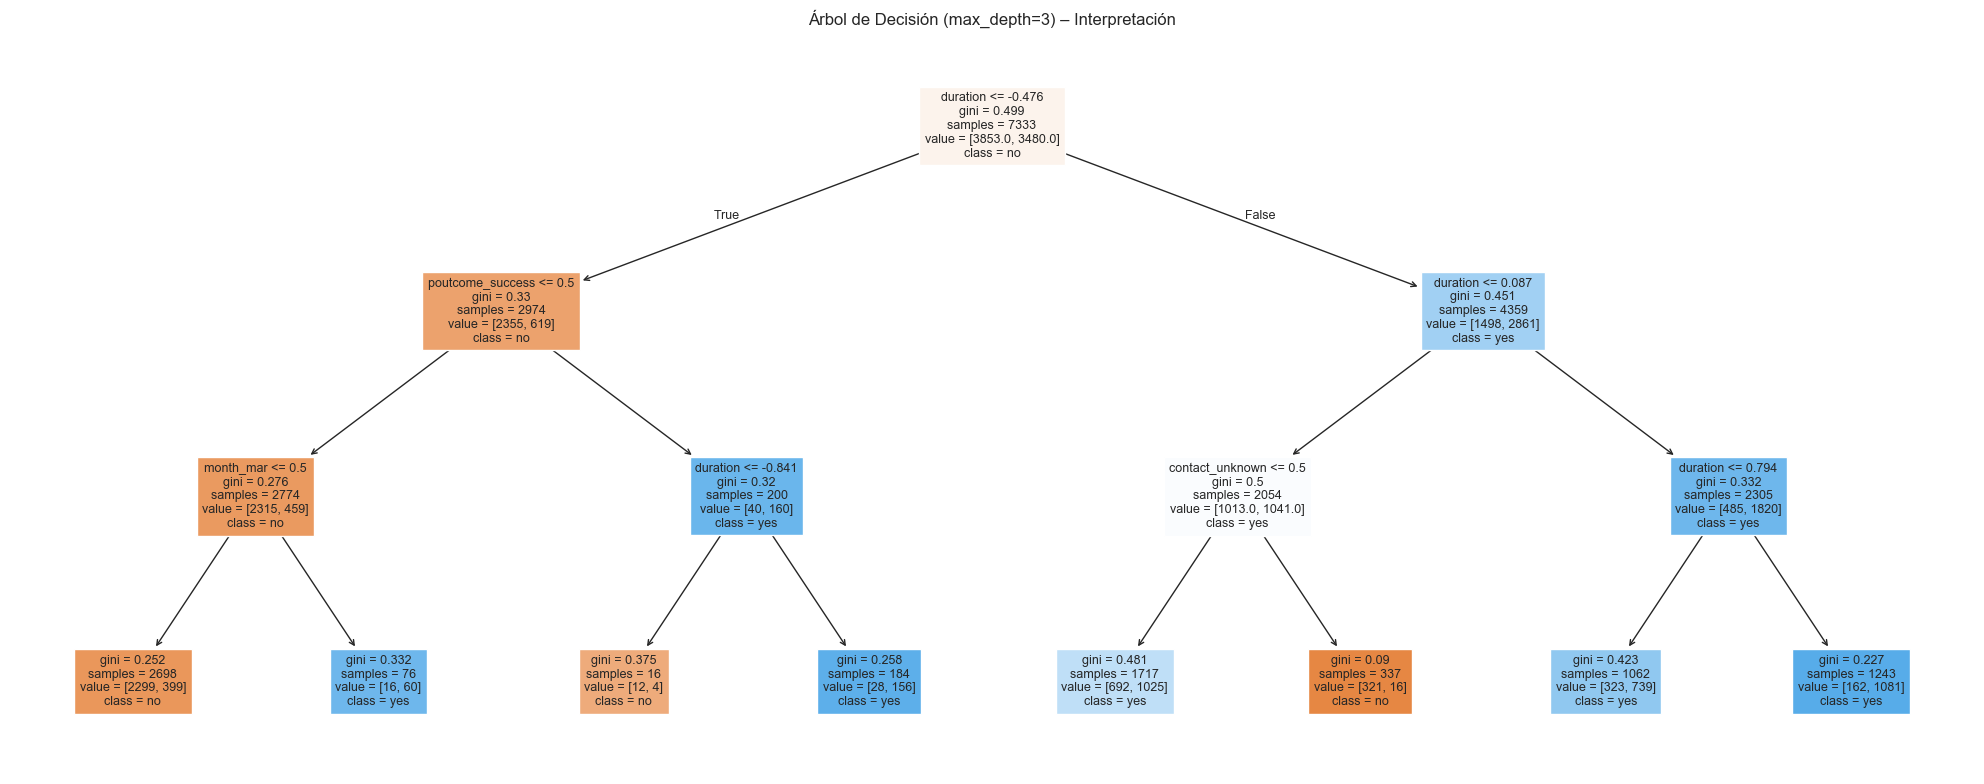

|--- duration <= -0.48
|   |--- poutcome_success <= 0.50
|   |   |--- month_mar <= 0.50
|   |   |   |--- class: 0
|   |   |--- month_mar >  0.50
|   |   |   |--- class: 1
|   |--- poutcome_success >  0.50
|   |   |--- duration <= -0.84
|   |   |   |--- class: 0
|   |   |--- duration >  -0.84
|   |   |   |--- class: 1
|--- duration >  -0.48
|   |--- duration <= 0.09
|   |   |--- contact_unknown <= 0.50
|   |   |   |--- class: 1
|   |   |--- contact_unknown >  0.50
|   |   |   |--- class: 0
|   |--- duration >  0.09
|   |   |--- duration <= 0.79
|   |   |   |--- class: 1
|   |   |--- duration >  0.79
|   |   |   |--- class: 1



In [18]:
# ── Árbol poco profundo para interpretación ───────────────────────────────
from sklearn.tree import plot_tree

pipe_shallow = Pipeline([
    ('pre', make_preprocessor(StandardScaler())),
    ('clf', DecisionTreeClassifier(max_depth=3, random_state=SEED))
])
pipe_shallow.fit(X_train, y_train)

# Obtener nombres de features transformados
num_names = num_features
cat_names = pipe_shallow.named_steps['pre']\
    .named_transformers_['cat']\
    .named_steps['encoder']\
    .get_feature_names_out(cat_features).tolist()
all_names = num_names + cat_names

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(pipe_shallow.named_steps['clf'],
          feature_names=all_names,
          class_names=le.classes_,
          filled=True, fontsize=9, ax=ax)
ax.set_title('Árbol de Decisión (max_depth=3) – Interpretación')
plt.tight_layout()
plt.savefig('arbol_shallow.png', bbox_inches='tight')
plt.show()

print(export_text(pipe_shallow.named_steps['clf'], feature_names=all_names))

### 4.4 Optimización de hiperparámetros (HPO) – KNN y DecisionTree

In [19]:
# ── HPO KNN ───────────────────────────────────────────────────────────────
pipe_knn = Pipeline([
    ('pre', make_preprocessor(BEST_SCALER)),
    ('clf', KNeighborsClassifier())
])

param_grid_knn = {
    'clf__n_neighbors': [3, 5, 7, 11, 15, 21, 31],
    'clf__weights': ['uniform', 'distance'],
    'clf__metric': ['euclidean', 'manhattan']
}

t0 = time.time()
gs_knn = GridSearchCV(pipe_knn, param_grid_knn, scoring=METRIC,
                       cv=cv_inner, n_jobs=-1, refit=True)
gs_knn.fit(X_train, y_train)
elapsed_knn = time.time() - t0

print(f'KNN – Mejor ROC-AUC (CV): {gs_knn.best_score_:.4f}')
print(f'KNN – Mejores hiperparámetros: {gs_knn.best_params_}')
print(f'KNN – Tiempo HPO: {elapsed_knn:.1f}s')

KNN – Mejor ROC-AUC (CV): 0.8948
KNN – Mejores hiperparámetros: {'clf__metric': 'euclidean', 'clf__n_neighbors': 15, 'clf__weights': 'distance'}
KNN – Tiempo HPO: 23.7s


In [20]:
# ── HPO DecisionTree ──────────────────────────────────────────────────────
pipe_dt = Pipeline([
    ('pre', make_preprocessor(StandardScaler())),
    ('clf', DecisionTreeClassifier(random_state=SEED))
])

param_grid_dt = {
    'clf__max_depth': [3, 5, 7, 10, 15, None],
    'clf__min_samples_split': [2, 10, 20, 50],
    'clf__criterion': ['gini', 'entropy']
}

t0 = time.time()
gs_dt = GridSearchCV(pipe_dt, param_grid_dt, scoring=METRIC,
                      cv=cv_inner, n_jobs=-1, refit=True)
gs_dt.fit(X_train, y_train)
elapsed_dt = time.time() - t0

print(f'DecisionTree – Mejor ROC-AUC (CV): {gs_dt.best_score_:.4f}')
print(f'DecisionTree – Mejores hiperparámetros: {gs_dt.best_params_}')
print(f'DecisionTree – Tiempo HPO: {elapsed_dt:.1f}s')

DecisionTree – Mejor ROC-AUC (CV): 0.8867
DecisionTree – Mejores hiperparámetros: {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_split': 50}
DecisionTree – Tiempo HPO: 8.4s


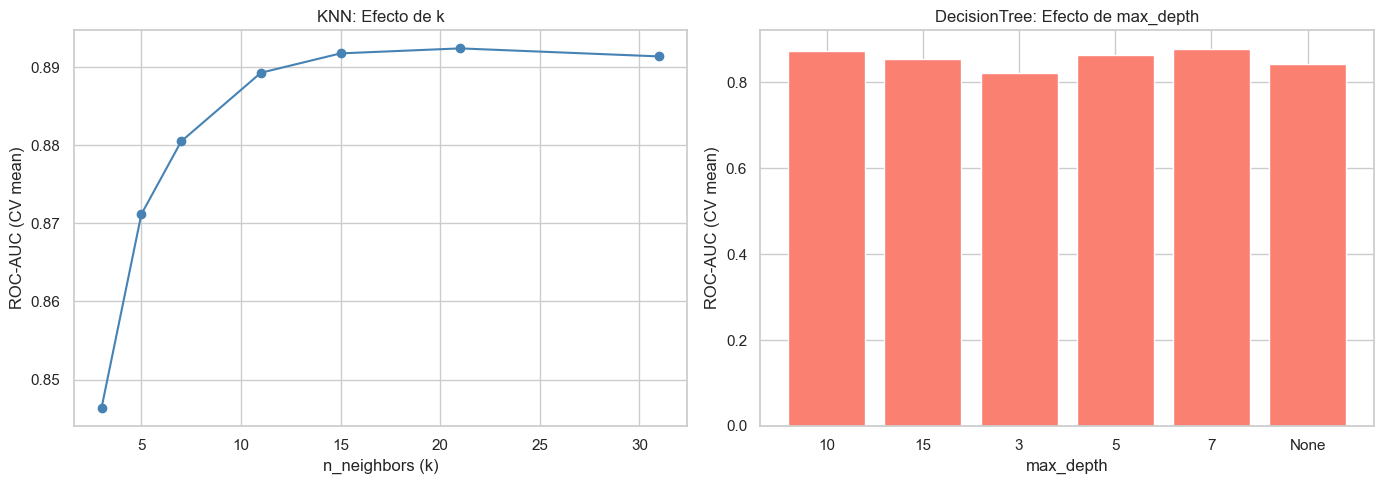

In [21]:
# ── Plot efecto de hiperparámetros ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KNN: n_neighbors vs ROC-AUC
knn_cv = pd.DataFrame(gs_knn.cv_results_)
knn_n = knn_cv.groupby('param_clf__n_neighbors')['mean_test_score'].mean().reset_index()
axes[0].plot(knn_n['param_clf__n_neighbors'], knn_n['mean_test_score'], 'o-', color='steelblue')
axes[0].set_xlabel('n_neighbors (k)')
axes[0].set_ylabel('ROC-AUC (CV mean)')
axes[0].set_title('KNN: Efecto de k')
axes[0].grid(True)

# DT: max_depth vs ROC-AUC
dt_cv = pd.DataFrame(gs_dt.cv_results_)
dt_cv['depth_label'] = dt_cv['param_clf__max_depth'].astype(str)
dt_d = dt_cv.groupby('depth_label')['mean_test_score'].mean().reset_index()
axes[1].bar(dt_d['depth_label'], dt_d['mean_test_score'], color='salmon')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('ROC-AUC (CV mean)')
axes[1].set_title('DecisionTree: Efecto de max_depth')
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.savefig('hpo_knn_dt.png')
plt.show()

In [22]:
# ── Resumen sección 4 ─────────────────────────────────────────────────────
resumen_s4 = pd.DataFrame([
    {'Modelo': 'KNN (default, k=5)', 'ROC-AUC': results_df[results_df['Modelo']=='KNN (k=5)']['ROC-AUC mean'].values[0], 'HPO': 'No'},
    {'Modelo': 'DecisionTree (default)', 'ROC-AUC': results_df[results_df['Modelo']=='DecisionTree']['ROC-AUC mean'].values[0], 'HPO': 'No'},
    {'Modelo': f'KNN (HPO)', 'ROC-AUC': round(gs_knn.best_score_, 4), 'HPO': 'Sí'},
    {'Modelo': f'DecisionTree (HPO)', 'ROC-AUC': round(gs_dt.best_score_, 4), 'HPO': 'Sí'},
]).sort_values('ROC-AUC', ascending=False)
display(resumen_s4)

print("""
CONCLUSIONES – Sección 4:
• HPO mejora los resultados respecto a valores por defecto en ambos modelos.
• El árbol de decisión con max_depth controlado evita sobreajuste.
• KNN es sensible al escalado; el mejor escalador reduce el efecto de outliers.
• Ambos modelos superan al modelo trivial (DummyClassifier).
• El coste de HPO de KNN puede ser elevado por el número de combinaciones.
""")

,Modelo,ROC-AUC,HPO
2,KNN (HPO),0.8948,Sí
3,DecisionTree (HPO),0.8867,Sí
0,"KNN (default, k=5)",0.8732,No
1,DecisionTree (default),0.7983,No



CONCLUSIONES – Sección 4:
• HPO mejora los resultados respecto a valores por defecto en ambos modelos.
• El árbol de decisión con max_depth controlado evita sobreajuste.
• KNN es sensible al escalado; el mejor escalador reduce el efecto de outliers.
• Ambos modelos superan al modelo trivial (DummyClassifier).
• El coste de HPO de KNN puede ser elevado por el número de combinaciones.

